[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_quantile_multiquantile_cqr.ipynb)

# CatBoost quantile bands: what they cover, and what conformalizing changes

A quantile loss fits one level of the conditional distribution. `MultiQuantile` fits a grid of them
in one model. Taking the outer pair as a 90% prediction interval is the obvious next step, and this
notebook measures what that interval covers on rows the model has not seen.

Three datasets from the conformalized quantile regression paper (Romano, Patterson and Candes,
NeurIPS 2019), spanning a 44-fold range in size: concrete at 1,030 rows, bike at 10,886,
casp at 45,730, read from the copies in the authors' repository. bike's datetime column is
expanded into hour, day of week, month and year.

Three ways to build the same band are compared throughout, because they are not equivalent:

- two separate `Quantile` models, one per level
- `MultiQuantile` on the outer pair
- `MultiQuantile` on ten levels, taking the outer pair from it

Runtime is about fifteen minutes on a laptop CPU and longer on a free Colab runtime, so the tables
below are worth reading before deciding to run it.

In [1]:
try:
    import catboost
except ImportError:
    !pip install -q catboost

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

## Setup

One place for every choice the experiment makes. Coverage uses eight seeds; the ten-level
comparisons cost ten fits each and use five.

In [3]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, CORAL_E, GREY_E = "#2C5F8A", "#C05F32", "#8a8a8a"
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
GUIDE_GREY = "#ededed"

ALPHA = 0.1
LO, HI = ALPHA / 2, 1 - ALPHA / 2
PAIR = [LO, HI]
TEN = [LO, *np.round(np.linspace(LO, HI, 10)[1:-1], 2), HI]   # rounded inside, exact ends
CONFIGS = {"300/0.05/d4": (300, 0.05, 4),
           "500/0.1/d6": (500, 0.1, 6),
           "1000/0.05/d6": (1000, 0.05, 6)}
NOM = 100 * (1 - ALPHA)
LIGHTEST, HARDEST = "300/0.05/d4", "1000/0.05/d6"
SWEEP_CFG = "500/0.1/d6"        # the config the sweep by pool size runs at
COVER_SEEDS, GRID_SEEDS = range(8), range(5)
SIZES = [500, 1000, 2000, 5000, 10000, 25000]
CFG_LABEL = {k: f"{i:,} rounds at {lr}, depth {d}" for k, (i, lr, d) in CONFIGS.items()}
BASE = "https://raw.githubusercontent.com/yromano/cqr/master/datasets/"

In [4]:
def concrete():
    d = pd.read_csv(BASE + "Concrete_Data.csv")
    return d.iloc[:, :-1], d.iloc[:, -1]


def bike():
    d = pd.read_csv(BASE + "bike_train.csv")
    t = pd.DatetimeIndex(d.datetime)
    d = d.assign(hour=t.hour, day=t.dayofweek, month=t.month, year=t.year)
    return d.drop(columns=["datetime", "casual", "registered", "count"]), d["count"]


def casp():
    d = pd.read_csv(BASE + "CASP.csv")
    return d.iloc[:, 1:], d.iloc[:, 0]


DATA = {"concrete": concrete(), "bike": bike(), "casp": casp()}

pd.DataFrame([{"dataset": k, "rows": len(y), "features": X.shape[1],
               "test rows": int(np.ceil(0.2 * len(y))), "target sd": round(y.std(), 2)}
              for k, (X, y) in DATA.items()])

,dataset,rows,features,test rows,target sd
0,concrete,1030,8,206,16.71
1,bike,10886,12,2178,181.14
2,casp,45730,9,9146,6.12


## The pinball loss

The loss charges τ per unit when the prediction lands below the truth and 1 − τ when it lands
above. Nothing else about the method is asymmetric.

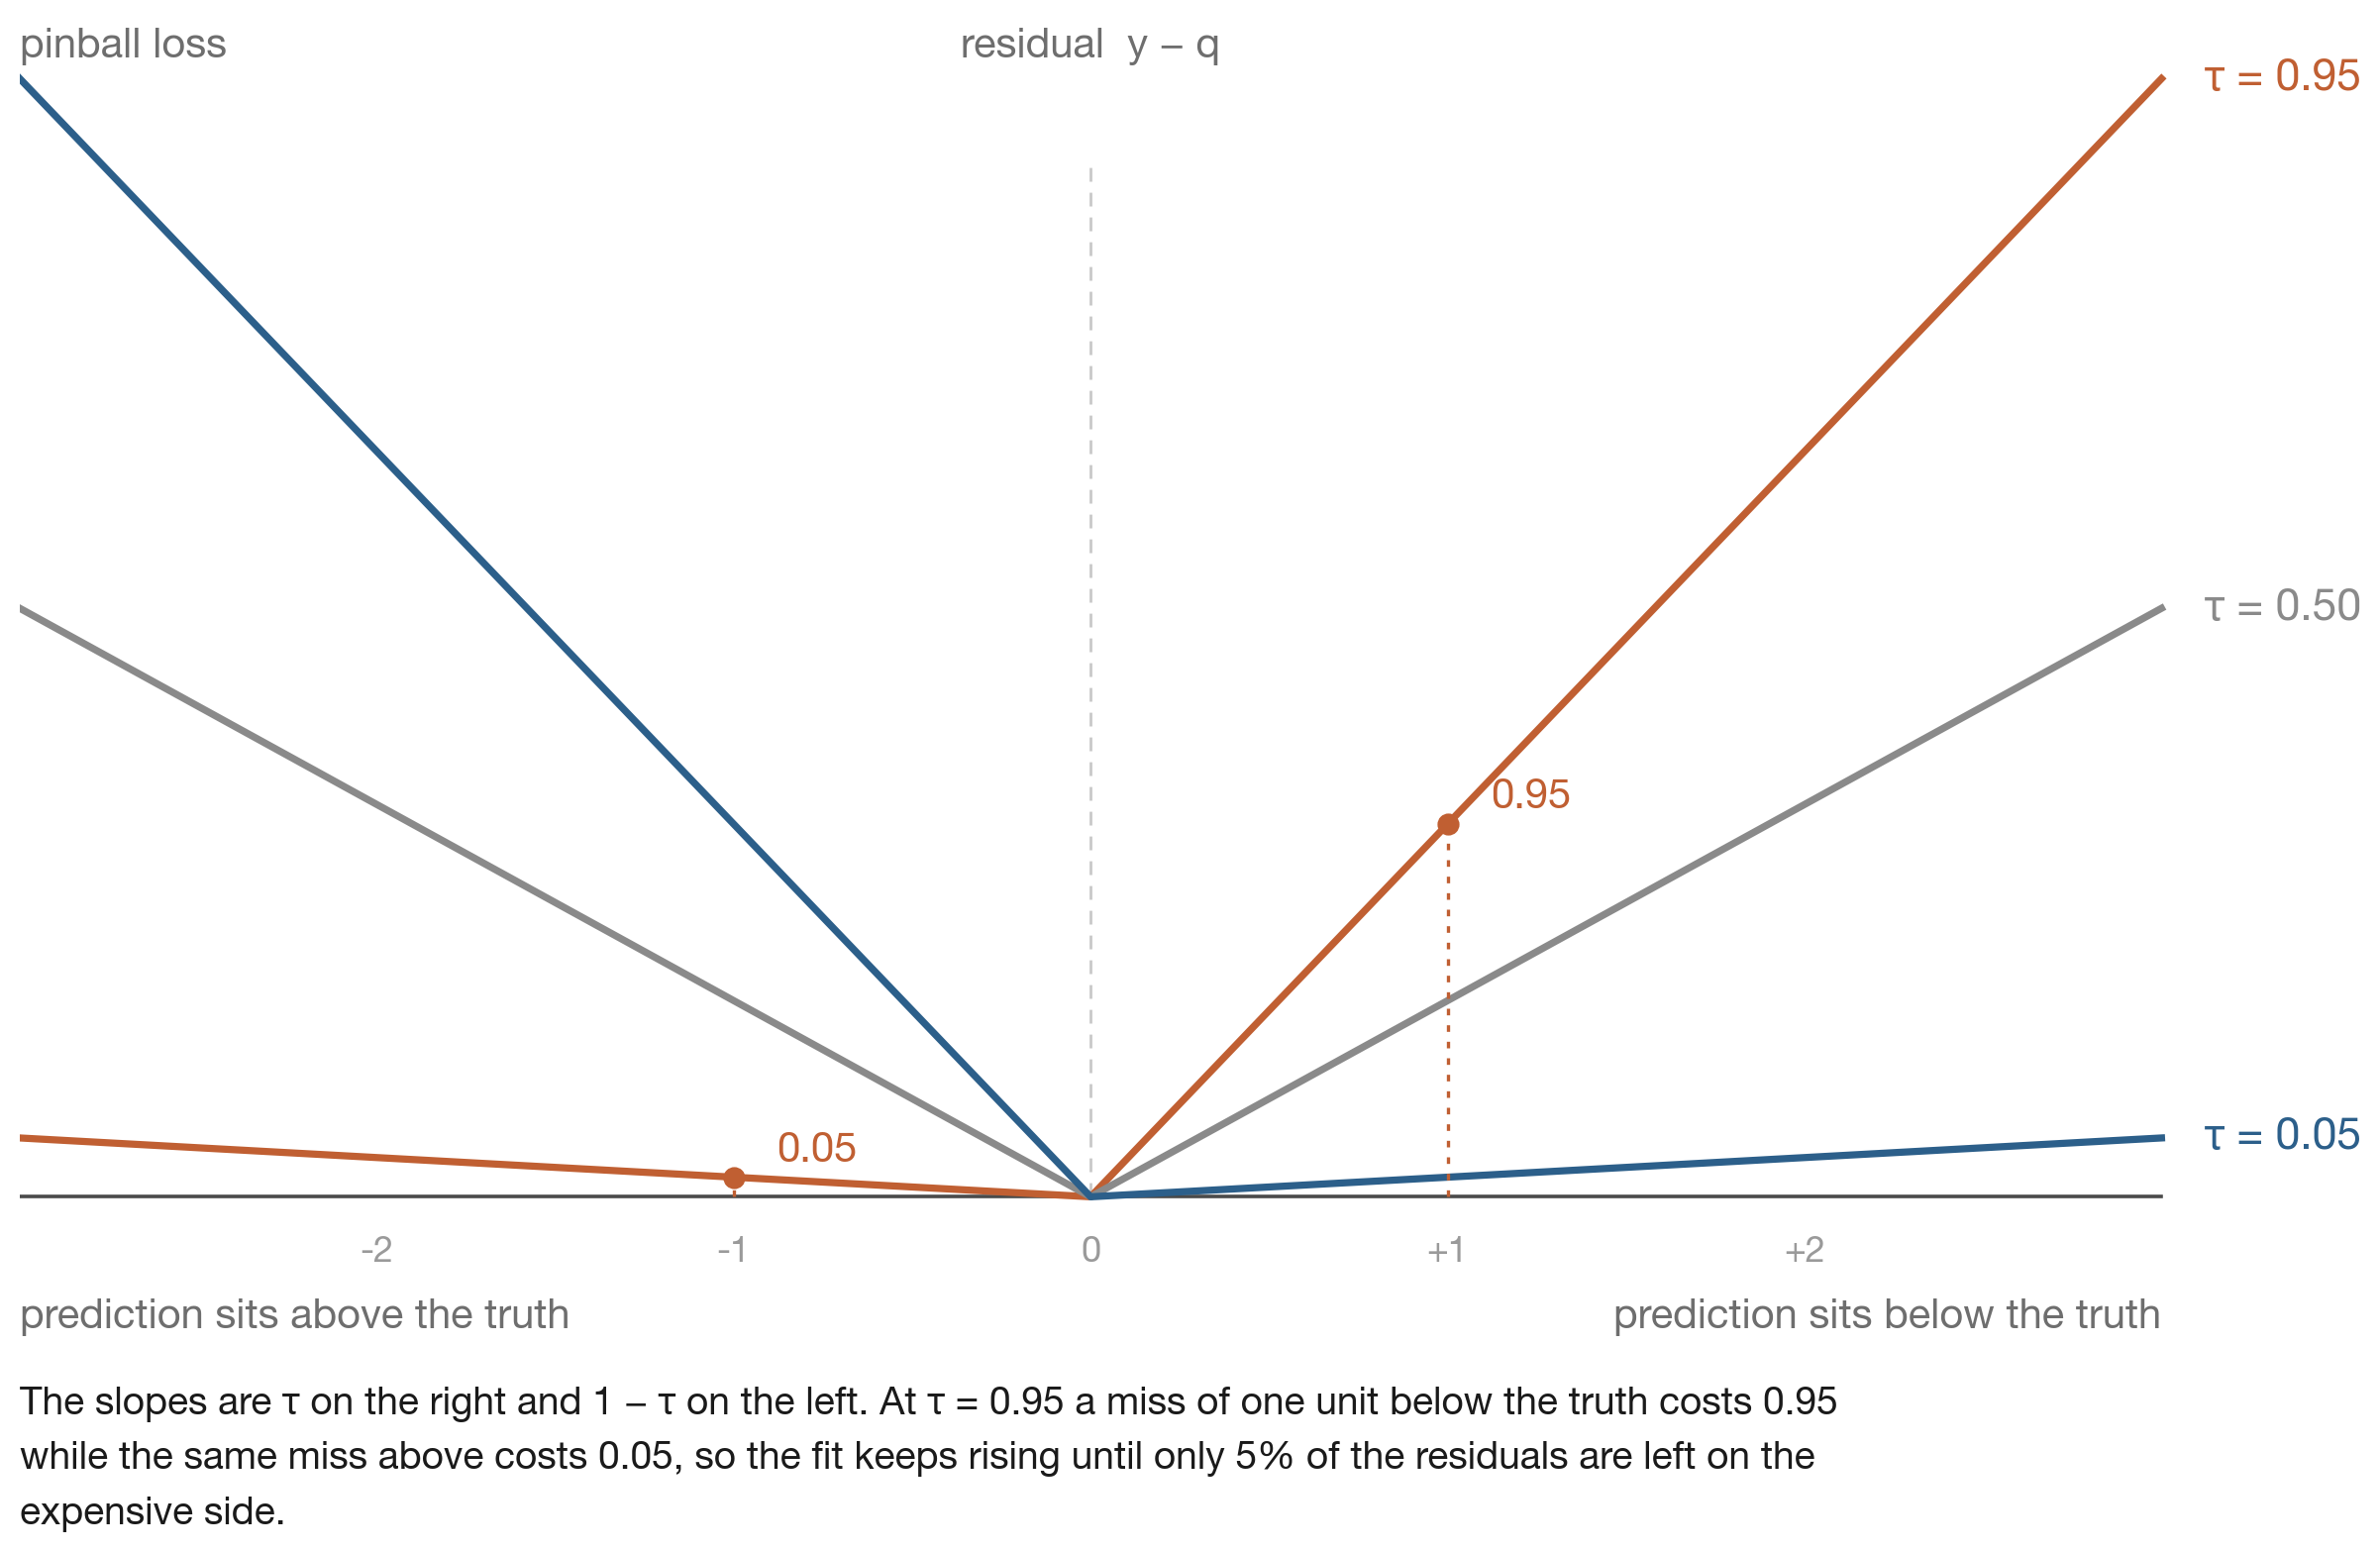

In [5]:
TAUS = [(0.95, CORAL_E), (0.50, GREY_E), (0.05, BLUE_E)]
XMIN, XMAX, YMAX = -3.0, 3.0, 3.0
u = np.linspace(XMIN, XMAX, 601)

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.055, 0.17, 0.79, 0.76])
ax.set_xlim(XMIN, XMAX + 0.05)
ax.set_ylim(-0.30, YMAX)
ax.axis("off")
ax.add_line(Line2D([XMIN, XMAX], [0, 0], color="#4a4a4a", lw=1.3, zorder=2))
ax.add_line(Line2D([0, 0], [0, YMAX - 0.35], color="#c9c9c9", lw=1.0, ls=(0, (5, 4)), zorder=1))

for tau, colour in TAUS:
    ax.plot(u, np.where(u > 0, tau * u, (1 - tau) * -u), color=colour, lw=2.6, zorder=3)
    ax.text(XMAX + 0.12, tau * XMAX, f"τ = {tau:.2f}", ha="left", va="center",
            fontsize=16, color=colour)

for side, height in ((1, 0.95), (-1, 0.05)):
    ax.add_line(Line2D([side, side], [0, height], color=CORAL_E, lw=1.2, ls=(0, (2, 3)), zorder=4))
    ax.plot([side], [height], "o", ms=7, color=CORAL_E, zorder=5)
    ax.text(side + 0.12, height + 0.02, f"{height:.2f}", ha="left", va="bottom",
            fontsize=15, color=CORAL_E)

for tick in (-2, -1, 0, 1, 2):
    ax.text(tick, -0.10, f"{tick:+g}" if tick else "0", ha="center", va="top",
            fontsize=13, color=TEXT_FAINT)
ax.text(0, YMAX - 0.02, "residual  y − q", ha="center", va="top",
        fontsize=15, color=TEXT_MUTED)
ax.text(XMIN, YMAX - 0.02, "pinball loss", ha="left", va="top", fontsize=15, color=TEXT_MUTED)
ax.text(XMIN, -0.26, "prediction sits above the truth", ha="left", va="top",
        fontsize=15, color=TEXT_MUTED)
ax.text(XMAX, -0.26, "prediction sits below the truth", ha="right", va="top",
        fontsize=15, color=TEXT_MUTED)
fig.text(0.055, 0.085,
         "The slopes are τ on the right and 1 − τ on the left. At τ = 0.95 a "
         "miss of one unit below the truth costs 0.95\nwhile the same miss above costs 0.05, so "
         "the fit keeps rising until only 5% of the residuals are left on the\nexpensive side.",
         ha="left", va="center", fontsize=14, color=INK, linespacing=1.7)
fig.savefig("catboost_quantile_pinball.png", facecolor="white")
plt.show()

## Fitting the levels

`fit_joint` and `fit_separate` are the only place the three arms differ: one model asked for
several levels, or one model per level.

In [6]:
def fit(X, y, qs, seed, cfg):
    iters, lr, depth = cfg
    loss = (f"Quantile:alpha={qs[0]}" if len(qs) == 1
            else f"MultiQuantile:alpha={','.join(map(str, qs))}")
    return CatBoostRegressor(loss_function=loss, iterations=iters, learning_rate=lr,
                             depth=depth, random_seed=seed, verbose=0,
                             allow_writing_files=False).fit(X, y)


def fit_joint(X, y, qs, seed, cfg):
    return [fit(X, y, qs, seed, cfg)]


def fit_separate(X, y, qs, seed, cfg):
    return [fit(X, y, [q], seed, cfg) for q in qs]


def predict_levels(models, Xte):
    """Levels come back in the order asked for and unsorted, since crossings are the thing
    the ten-level grid below measures. Sort at the call site, not here."""
    return np.column_stack([m.predict(Xte) for m in models])


ARMS = [("separate pair", PAIR, fit_separate),
        ("MultiQuantile pair", PAIR, fit_joint),
        ("MultiQuantile ten", TEN, fit_joint)]

## Where the levels share a structure

`MultiQuantile` keeps `leaf_estimation_method="Exact"`, the same as a single `Quantile` fit, so each
level still gets the weighted quantile of the residuals that landed in its leaf. Nothing is
approximated there. Whatever sharing costs has to come from one step earlier, in split selection,
where a single structure serves every alpha at once.

A synthetic case shows where the splits go. `x0` scales the upper tail only, `x1` the lower tail
only, and `x2` and `x3` are noise, so each of the two outer levels has a feature it needs and the
other has no use for.

In [7]:
def tails(seed, n=8000):
    """x0 scales the upper tail, x1 the lower one, x2 and x3 are noise."""
    r = np.random.default_rng(seed)
    Xs = r.uniform(0, 1, size=(n, 4))
    z = r.normal(size=n)
    return Xs, 10 + (1 + 6 * Xs[:, 0]) * np.maximum(z, 0) - (1 + 6 * Xs[:, 1]) * np.maximum(-z, 0)


Xs, ys = tails(0)
for loss in ("RMSE", "Quantile:alpha=0.95", "MultiQuantile:alpha=0.05,0.95"):
    m = CatBoostRegressor(loss_function=loss, iterations=5, verbose=0,
                          allow_writing_files=False).fit(Xs, ys)
    print(f"{loss:31} leaf_estimation_method={m.get_all_params()['leaf_estimation_method']}")

RMSE                            leaf_estimation_method=Newton
Quantile:alpha=0.95             leaf_estimation_method=Exact
MultiQuantile:alpha=0.05,0.95   leaf_estimation_method=Exact


In [8]:
IMP_ARMS = {f"Quantile {HI}": [HI], f"Quantile {LO}": [LO], "MultiQuantile, the pair": PAIR}
imp_rows = []
for s in GRID_SEEDS:
    Xs, ys = tails(s)
    for label, qs in IMP_ARMS.items():
        m = fit(Xs, ys, qs, s, CONFIGS[LIGHTEST])
        imp_rows.append({"fit": label, "seed": s,
                         **dict(zip(["x0", "x1", "x2", "x3"], m.get_feature_importance()))})
IMP = pd.DataFrame(imp_rows)
joint = IMP[IMP.fit == "MultiQuantile, the pair"]
print(f"the joint fit puts more on x0 than on x1 in "
      f"{(joint.x0 > joint.x1).sum()} of {len(joint)} seeds")
IMP.drop(columns="seed").groupby("fit", sort=False).agg(["mean", "min", "max"]).round(1)

the joint fit puts more on x0 than on x1 in 2 of 5 seeds


x0                x1                x2             \
                         mean   min   max  mean   min   max  mean  min   max   
fit                                                                            
Quantile 0.95            69.9  66.7  73.3  10.2   8.1  11.1   9.6  7.8  11.8   
Quantile 0.05            10.2   8.6  12.6  69.1  64.7  72.5  10.7  8.8  13.3   
MultiQuantile, the pair  39.3  35.4  42.5  44.0  40.5  48.8   8.5  7.9   9.4   

                           x3             
                         mean  min   max  
fit                                       
Quantile 0.95            10.3  8.8  11.3  
Quantile 0.05            10.0  8.8  11.4  
MultiQuantile, the pair   8.2  7.2   9.4

Each separate fit puts about 70 points of importance on the one feature its own tail needs and
about 10 on each of the other three. The joint fit splits on both, near 40 points each.

That table says where the splits went and nothing about what the sharing cost. Importance is
normalised to sum to 100 and pooled over the model's outputs, so a joint model serving two tails
would read near 40/40 whether it compromised or built two disjoint sets of splits, one per level.
The near-40s here are close to the average of the two separate fits, 40.1 and 39.7, which is what
pooling predicts on its own. The overlapping min and max columns say the split is not stable
either, and the line below counts how often it changes sign.

The cost has to be measured on a loss. Below, each arm is fitted on one draw and scored on a fresh
one, at the lightest and the hardest of the three configs.

In [9]:
def levels(p, y):
    """The share of rows each predicted level actually covers, one number per column."""
    return 100 * (y[:, None] <= p).mean(axis=0)


def pinball(y, p, q):
    d = y - p
    return float(np.mean(np.maximum(q * d, (q - 1) * d)))


SHARE_LABEL = {"separate pair": "two separate fits",
               "MultiQuantile pair": "MultiQuantile, the pair",
               "MultiQuantile ten": "MultiQuantile, ten levels"}
share_rows = []
for cname in (LIGHTEST, HARDEST):
    for s in GRID_SEEDS:
        Xs, ys = tails(s)
        Xo, yo = tails(s + 100)                        # a draw the fit has never seen
        for aname, qs, strategy in ARMS:
            i, j = qs.index(LO), qs.index(HI)
            p = predict_levels(strategy(Xs, ys, qs, s, CONFIGS[cname]), Xo)
            share_rows.append({
                "config": cname, "arm": SHARE_LABEL[aname], "seed": s,
                f"pinball at {LO}": pinball(yo, p[:, i], LO),
                f"pinball at {HI}": pinball(yo, p[:, j], HI),
                f"level at {HI}": levels(p[:, [j]], yo)[0]})
SHARE = pd.DataFrame(share_rows)
SHARE.drop(columns="seed").groupby(["config", "arm"], sort=False).mean().round(4)

pinball at 0.05  pinball at 0.95  \
config       arm                                                           
300/0.05/d4  two separate fits                   0.4198           0.4151   
             MultiQuantile, the pair             0.4204           0.4160   
             MultiQuantile, ten levels           0.4196           0.4156   
1000/0.05/d6 two separate fits                   0.4443           0.4415   
             MultiQuantile, the pair             0.4567           0.4502   
             MultiQuantile, ten levels           0.4763           0.4756   

                                        level at 0.95  
config       arm                                       
300/0.05/d4  two separate fits                94.2875  
             MultiQuantile, the pair          94.3500  
             MultiQuantile, ten levels        94.3125  
1000/0.05/d6 two separate fits                92.3500  
             MultiQuantile, the pair          92.2025  
             MultiQuantile, ten levels        90.5700

At the light config sharing costs nothing: the three arms sit within 0.001 of each other on both
pinball losses, and which one is best changes with the level. At the hard config the pair pays about
2% of pinball loss over two separate fits and ten levels pays about 7%, with the achieved level at
the upper quantile falling from 92.4 to 90.6 against a nominal 95.

So the cost is not a property of the loss. It appears when the structure runs out of room, and it
grows with the number of levels asked to share it. That is the same ordering the three real datasets
show, and it is why the tables below separate the pair from the ten-level arm.

## Conformalizing the band

The recipe is one step long: hold out rows the model never saw, measure how far the band missed on
them, and widen it by that much. What the held-out rows buy is a statement about new rows that the
fitted levels cannot make on their own.

Following Romano et al. (NeurIPS 2019): the score is `max(q_lo - y, y - q_hi)` (eq. 6), the
interval widens by a single correction on both sides (eq. 7), and that correction is the
`(1 - alpha)(1 + 1/n)` empirical quantile of the scores (eq. 8). A score is negative when the
band already contains the row, which is how the correction can narrow the band rather than only
widen it.

Writing eq. 8 as a call needs care. `np.quantile(..., method="higher")` returns the k-th smallest
score for every calibration size this notebook uses, though not for every n: it takes the next
score up whenever `(1 - alpha)(n + 1)` lands exactly on an integer. Applying `ceil` before
dividing takes the one after it at every n, which is conservative but not what the paper says.

In [10]:
def shift(lo, hi, y):
    e = np.maximum(lo - y, y - hi)
    n = len(e)
    return np.quantile(e, min(1.0, (1 - ALPHA) * (1 + 1 / n)), method="higher")


def cover(lo, hi, y):
    return 100 * ((y >= lo) & (y <= hi)).mean()


def protocols(Xp, yp, Xte, yte, qs, seed, cfg, strategy):
    """Raw band on the whole pool, then the same recipe split in half to calibrate."""
    i, j = qs.index(LO), qs.index(HI)
    p = predict_levels(strategy(Xp, yp, qs, seed, cfg), Xte)
    rc = cover(p[:, i], p[:, j], yte)
    Xtr, Xca, ytr, yca = train_test_split(Xp, yp, test_size=0.5, random_state=seed)
    half = strategy(Xtr, ytr, qs, seed, cfg)
    pc, pt = predict_levels(half, Xca), predict_levels(half, Xte)
    q = shift(pc[:, i], pc[:, j], yca.values)
    hc = cover(pt[:, i], pt[:, j], yte)
    cc = cover(pt[:, i] - q, pt[:, j] + q, yte)
    return {"raw": rc, "half": hc, "cqr": cc}

## What the band covers

Every arm is evaluated on the same held-out fifth of the data. `raw` trains on the rest, `half`
trains on half of it, and `cqr` conformalizes that halved model on the other half. Comparing `raw`
with `cqr` therefore mixes the correction with the training rows given up for calibration, which
is why `half` is reported next to them.

In [11]:
cover_rows = []
for name, (X, y) in DATA.items():
    for s in COVER_SEEDS:
        Xp, Xte, yp, yte = train_test_split(X, y, test_size=0.2, random_state=s)
        for cname, cfg in CONFIGS.items():
            for aname, qs, strategy in ARMS:
                cover_rows.append({"data": name, "config": cname, "arm": aname, "seed": s,
                                   **protocols(Xp, yp, Xte, yte, qs, s, cfg, strategy)})
cover_df = pd.DataFrame(cover_rows)
means = cover_df.groupby(["data", "config", "arm"])["raw"].mean()   # the arms figure reads this
cover_df.pivot_table(index=["data", "config"], columns="arm",
                     values=["raw", "half", "cqr"]).round(2)

cqr                                  \
arm                   MultiQuantile pair MultiQuantile ten separate pair   
data     config                                                            
bike     1000/0.05/d6              90.12             89.98         90.36   
         300/0.05/d4               90.09             90.04         89.86   
         500/0.1/d6                89.86             90.19         90.00   
casp     1000/0.05/d6              89.99             89.99         89.95   
         300/0.05/d4               90.21             90.18         90.18   
         500/0.1/d6                90.06             90.15         90.03   
concrete 1000/0.05/d6              91.32             90.41         89.87   
         300/0.05/d4               89.93             90.11         89.62   
         500/0.1/d6                90.41             89.68         89.75   

                                    half                                  \
arm                   MultiQuantile pair MultiQuantile ten separate pair   
data     config                                                            
bike     1000/0.05/d6              82.80             74.67         82.01   
         300/0.05/d4               88.21             88.35         87.74   
         500/0.1/d6                82.66             74.49         80.95   
casp     1000/0.05/d6              84.13             82.51         84.41   
         300/0.05/d4               89.26             89.29         89.17   
         500/0.1/d6                84.42             82.65         84.44   
concrete 1000/0.05/d6              62.01             43.39         58.80   
         300/0.05/d4               75.79             68.99         75.67   
         500/0.1/d6                61.83             44.05         59.04   

                                     raw                                  
arm                   MultiQuantile pair MultiQuantile ten separate pair  
data     config                                                           
bike     1000/0.05/d6              85.70             80.99         84.50  
         300/0.05/d4               89.35             89.51         89.05  
         500/0.1/d6                85.62             80.96         84.66  
casp     1000/0.05/d6              86.59             86.24         86.38  
         300/0.05/d4               89.80             89.74         89.70  
         500/0.1/d6                86.46             86.17         86.46  
concrete 1000/0.05/d6              72.69             55.58         70.87  
         300/0.05/d4               81.61             79.98         81.74  
         500/0.1/d6                73.06             57.46         72.15

In [12]:
print(f"seed-averaged raw bands reaching {NOM:.0f}%: {(means >= NOM).sum()} of {len(means)}")
print(f"they run from {means.min():.2f}% to {means.max():.2f}%")
print(f"single runs reached {cover_df['raw'].max():.2f}%")
print()
print("conformalized coverage, by dataset:")
print(cover_df.groupby("data")["cqr"].agg(["mean", "std", "min", "max"]).round(2).to_string())

seed-averaged raw bands reaching 90%: 0 of 27
they run from 55.58% to 89.80%
single runs reached 90.27%

conformalized coverage, by dataset:
           mean   std    min    max
data                               
bike      90.06  0.55  88.48  91.32
casp      90.08  0.29  89.37  90.87
concrete  90.12  2.64  83.98  95.15


Two effects sit in that table.

How hard the trees are fitted lowers coverage on every arm and every dataset. The fitted quantiles
are placed to bracket the training rows; new rows fall outside them more often, so the band comes
out too narrow.

Asking one model for ten levels costs on top of that, and the two effects are not ordered the same
way everywhere. `MultiQuantile` on the pair and two separate models agree closely throughout, which
puts the penalty on one structure serving ten levels rather than on the loss. Reading the `raw`
column, the ten-level arm costs 1.7 points against the mean of the two pair arms on concrete at the
light config and nothing on bike or casp, then 15 to 16 points on concrete once the fit is hard,
about 4 on bike and about 0.3 on casp. On concrete at the hardest config that arm gap, 17.1 points,
is wider than the whole config effect on either pair arm, 8.9 and 10.9 points.

The conformalized numbers centre on the nominal level on all three datasets. The guarantee is
marginal, meaning it holds averaged over the calibration and test draws together rather than on
any one slice, so the spread around it is a finite-sample matter on either side:
concrete calibrates on 412 rows and measures on 206, against 18,292 and 9,146 for casp.

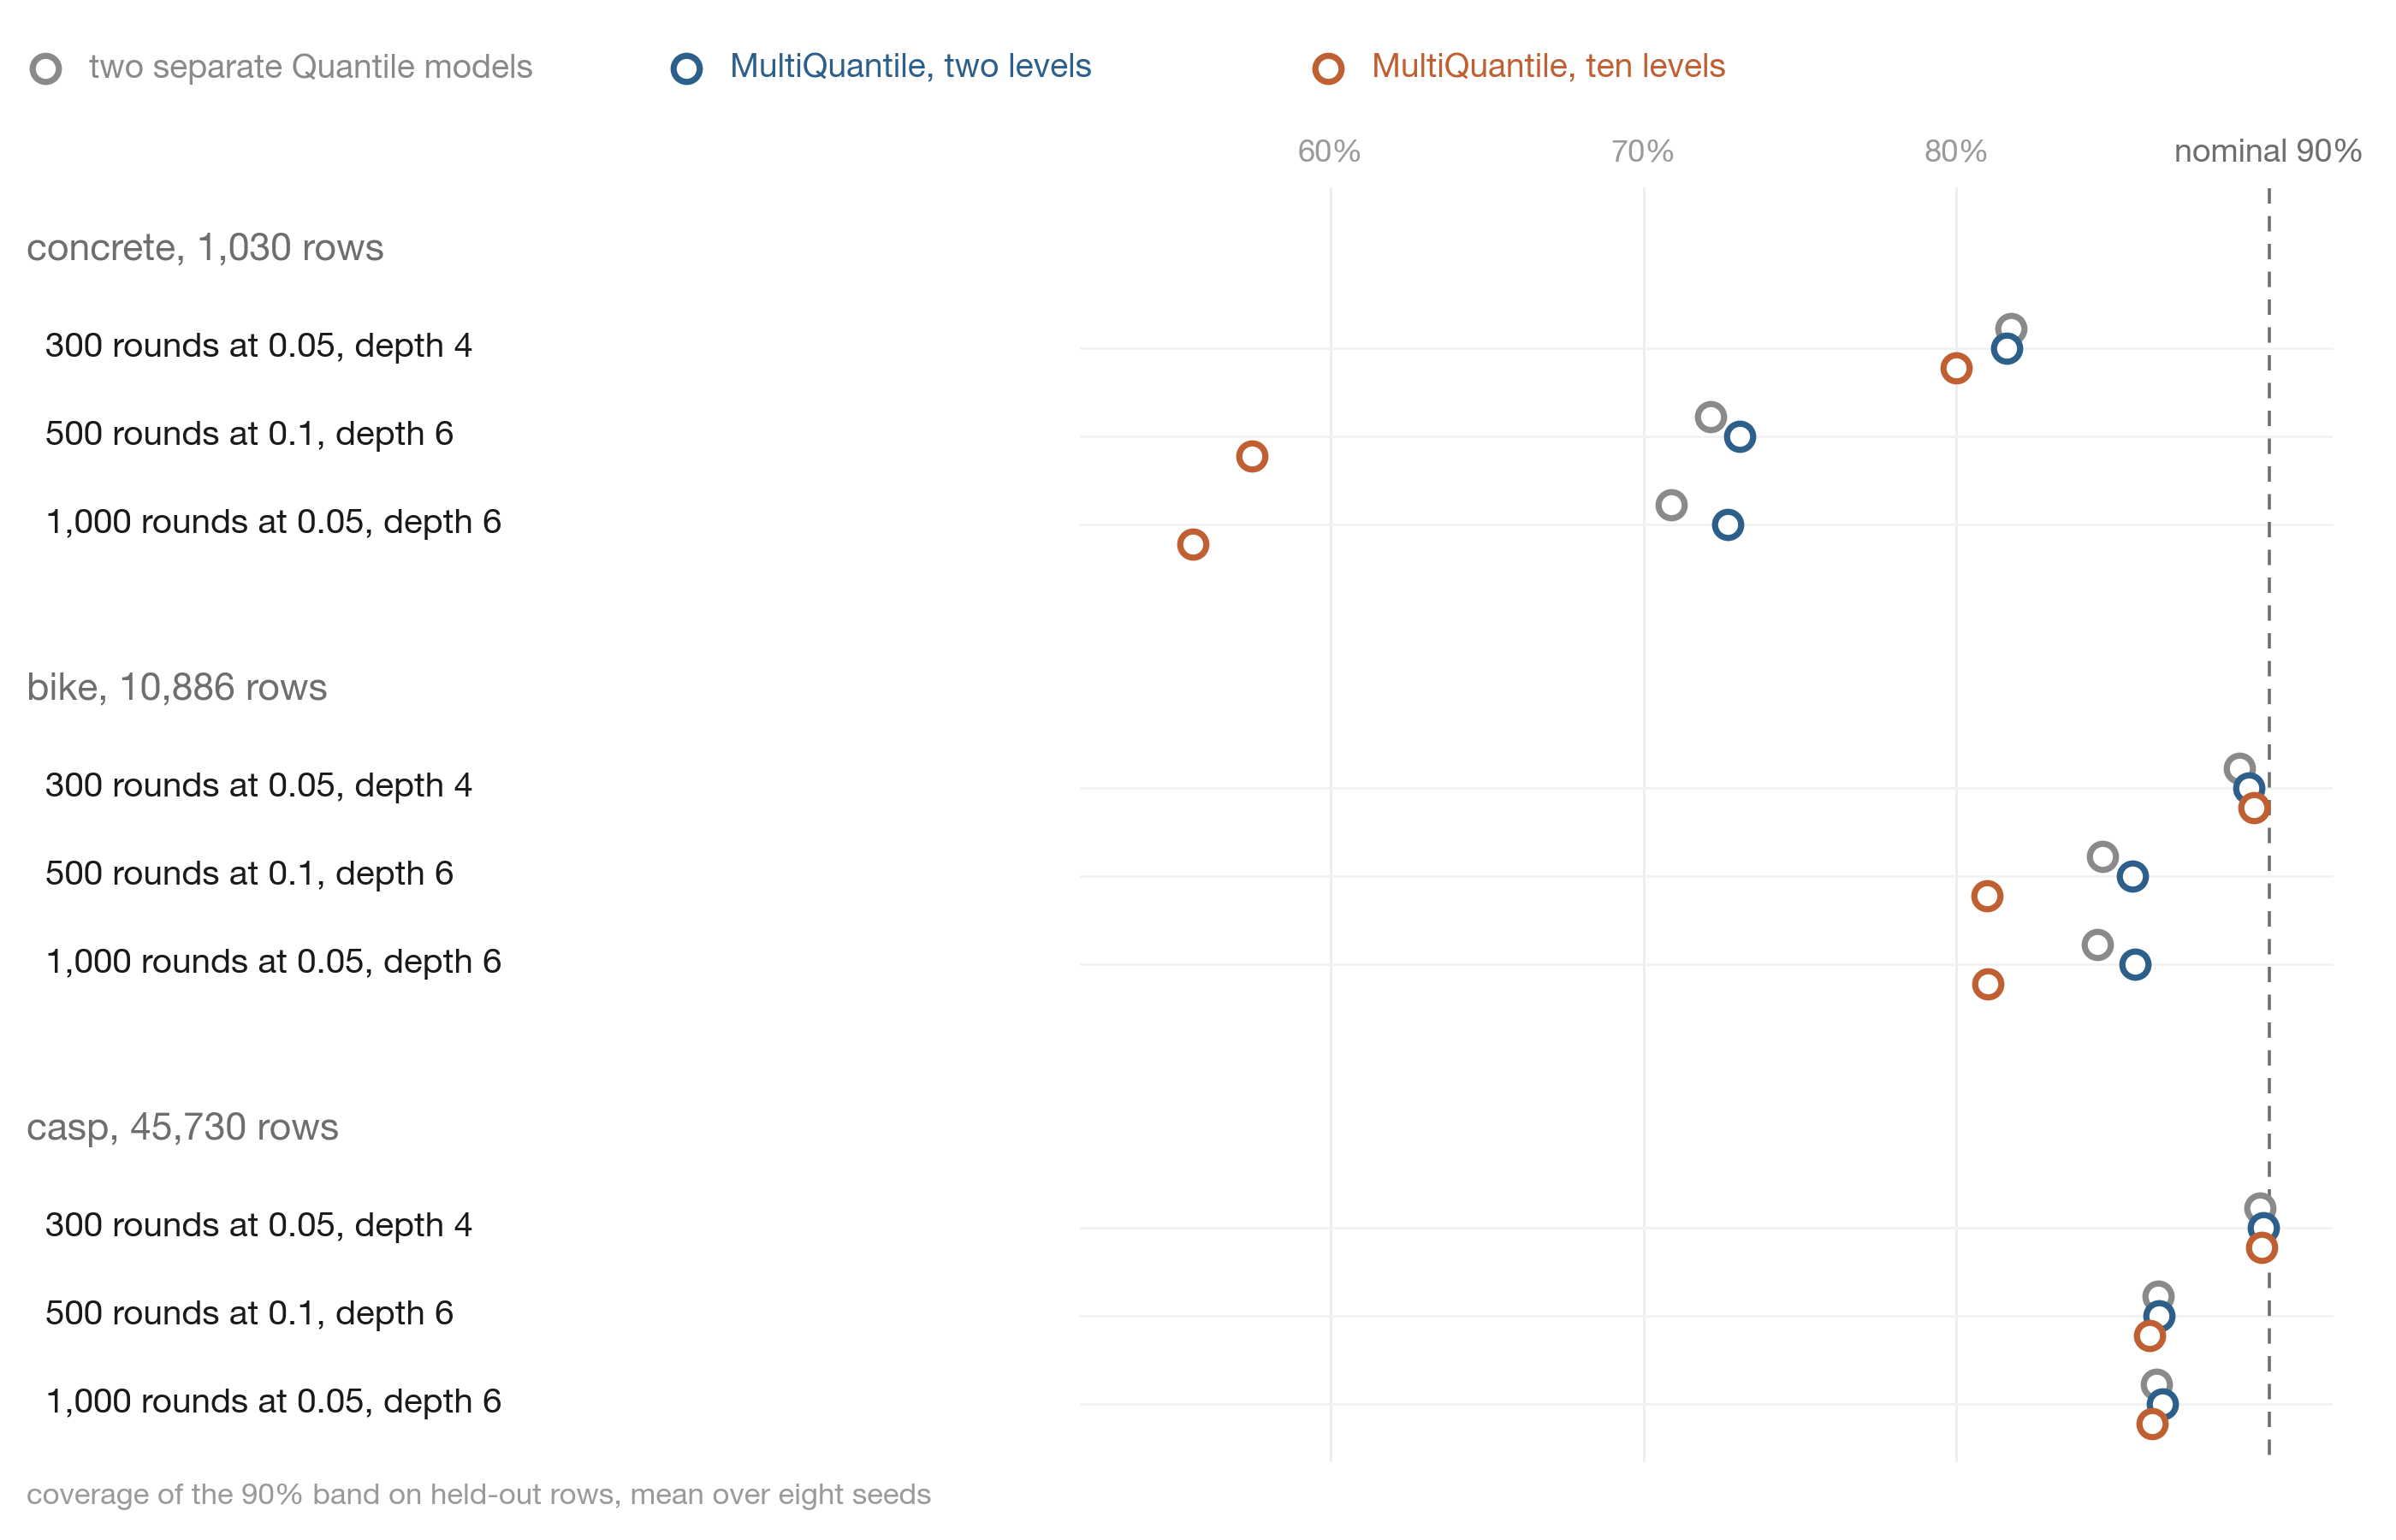

In [13]:
ARM_STYLE = {"separate pair": (GREY_E, "two separate Quantile models"),
             "MultiQuantile pair": (BLUE_E, "MultiQuantile, two levels"),
             "MultiQuantile ten": (CORAL_E, "MultiQuantile, ten levels")}
XL, XR, LEFT = 52.0, 92.0, 18.0
OFFSETS = (-0.19, 0.0, 0.19)
points, heads, cursor = [], [], 0.9
for name in DATA:
    heads.append((cursor, f"{name}, {len(DATA[name][1]):,} rows"))
    cursor += 0.95
    for cname in CONFIGS:
        points.append((cursor, CFG_LABEL[cname],
                       [(means[(name, cname, a)], ARM_STYLE[a][0], dy)
                        for a, dy in zip(ARM_STYLE, OFFSETS)]))
        cursor += 0.85
    cursor += 0.75
YTOP = points[-1][0] + 1.15
GUIDE = points[-1][0] + 0.55

fig = plt.figure(figsize=(13.8, 8.8), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(LEFT, XR + 1.5)
ax.set_ylim(YTOP, -1.35)
ax.axis("off")
ax.add_line(Line2D([NOM, NOM], [0.30, GUIDE], color=TEXT_MUTED, lw=1.3,
                   ls=(0, (5, 4)), zorder=1))
ax.text(NOM, 0.10, f"nominal {NOM:.0f}%", ha="center", va="bottom", fontsize=13.5,
        color=TEXT_MUTED)
for tick in (60, 70, 80):
    ax.add_line(Line2D([tick, tick], [0.30, GUIDE], color=GUIDE_GREY, lw=1.0, zorder=0))
    ax.text(tick, 0.10, f"{tick}%", ha="center", va="bottom", fontsize=13, color=TEXT_FAINT)
for cy, label in heads:
    ax.text(LEFT + 0.3, cy, label, ha="left", va="center", fontsize=16, color=TEXT_MUTED)
for cy, label, vals in points:
    ax.add_line(Line2D([XL, XR], [cy] * 2, color="#f2f2f2", lw=1.0, zorder=0))
    ax.text(LEFT + 0.9, cy, label, ha="left", va="center", fontsize=14.5, color=INK)
    for v, colour, dy in vals:
        ax.plot([v], [cy + dy], "o", ms=11, color=colour, zorder=4,
                markerfacecolor="white", markeredgewidth=2.6)
for i, (colour, label) in enumerate(ARM_STYLE.values()):
    ax.plot([LEFT + 0.9 + i * 20.5], [-0.85], "o", ms=11, color=colour,
            markerfacecolor="white", markeredgewidth=2.6, clip_on=False)
    ax.text(LEFT + 2.3 + i * 20.5, -0.85, label, ha="left", va="center",
            fontsize=14, color=colour, clip_on=False)
ax.text(LEFT + 0.3, YTOP - 0.25,
        "coverage of the 90% band on held-out rows, mean over eight seeds",
        ha="left", va="center", fontsize=12.5, color=TEXT_FAINT)
fig.savefig("catboost_quantile_arms.png", facecolor="white")
plt.show()

## How much of it is the number of rows

Same dataset, same settings, same held-out test set at every size. Only the training pool is
subsampled, so nothing but the number of training rows changes along the sweep. The conformalized
curve splits that pool in half, training on one half and calibrating on the other.

In [14]:
X, y = DATA["casp"]
size_rows = []
for s in COVER_SEEDS:
    Xp, Xte, yp, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    for n in SIZES + [len(Xp)]:
        idx = Xp.sample(n, random_state=s).index if n < len(Xp) else Xp.index
        size_rows.append({"train rows": n, "seed": s,
                          **protocols(Xp.loc[idx], yp.loc[idx], Xte, yte, PAIR, s,
                                CONFIGS[SWEEP_CFG], fit_separate)})
size_df = pd.DataFrame(size_rows)
size_summary = size_df.groupby("train rows")[["raw", "cqr"]].agg(["mean", "min", "max"])
size_summary.round(2)

raw                  cqr              
             mean    min    max   mean    min    max
train rows                                          
500         61.44  57.58  65.47  90.01  86.20  93.90
1000        67.62  64.30  71.99  89.98  89.34  90.67
2000        71.81  69.11  75.97  90.13  88.94  91.03
5000        78.82  76.83  80.60  90.08  89.25  90.68
10000       82.18  80.89  83.45  90.27  89.54  90.83
25000       85.59  85.23  86.03  89.97  89.42  90.40
36584       86.46  86.20  86.86  90.03  89.57  90.45

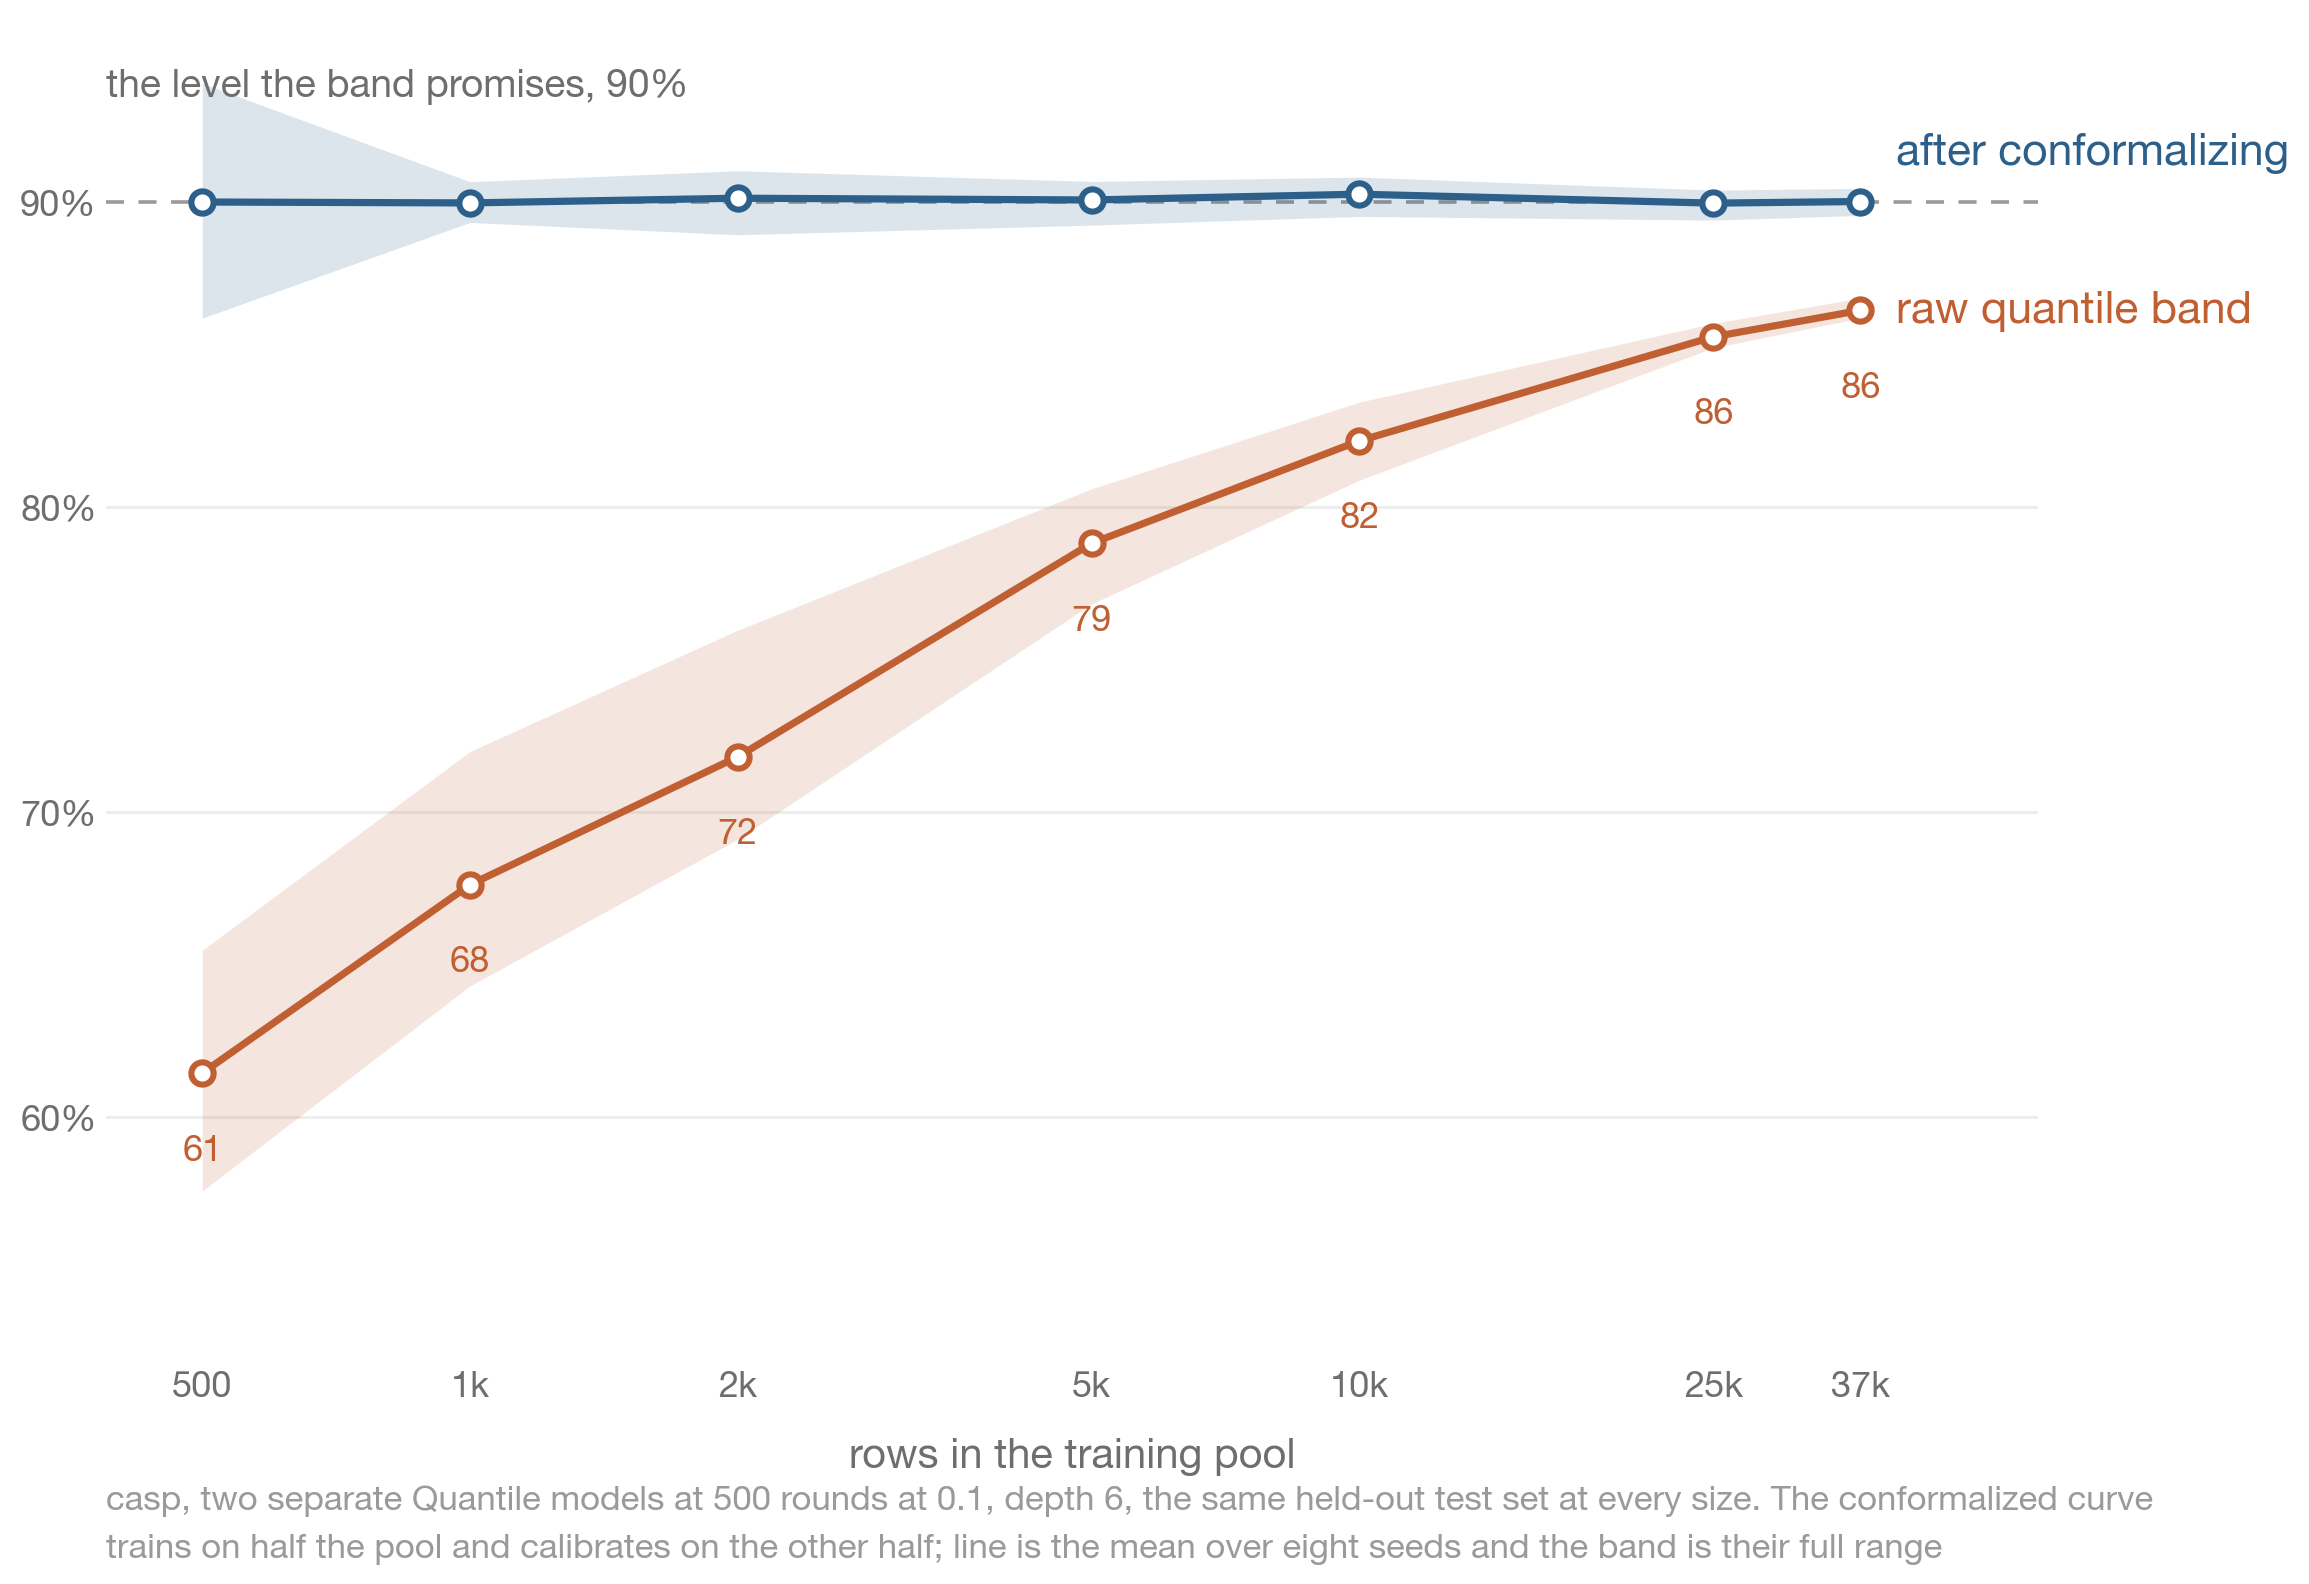

In [15]:
d = size_summary
x = np.log10(d.index.values)
LX, RX = np.log10(390), np.log10(58000)

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.075, 0.15, 0.70, 0.78])
ax.set_xlim(LX, RX)
ax.set_ylim(52.0, 96.0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.tick_params(length=0, labelsize=13, colors=TEXT_MUTED)
for g in (60, 70, 80):
    ax.axhline(g, color=GUIDE_GREY, lw=1.0, zorder=0)
ax.axhline(NOM, color=TEXT_FAINT, lw=1.3, ls=(0, (5, 4)), zorder=1)
ax.text(LX, 93.2, "the level the band promises, 90%", ha="left", va="bottom",
        fontsize=14, color=TEXT_MUTED)
for col, colour, label, dy in (("cqr", BLUE_E, "after conformalizing", 1.6),
                               ("raw", CORAL_E, "raw quantile band", 0.0)):
    ax.fill_between(x, d[(col, "min")], d[(col, "max")], color=colour, alpha=0.16,
                    lw=0, zorder=2)
    ax.plot(x, d[(col, "mean")], "-o", color=colour, lw=2.6, ms=8, zorder=3,
            markerfacecolor="white", markeredgewidth=2.2)
    ax.text(x[-1] + 0.04, d[(col, "mean")].iloc[-1] + dy, label, ha="left", va="center",
            fontsize=16, color=colour)
for xi, v in zip(x, d[("raw", "mean")]):
    ax.text(xi, v - 2.0, f"{v:.0f}", ha="center", va="top", fontsize=13, color=CORAL_E)
ax.set_xticks(x)
ax.set_xticklabels([f"{round(n / 1000)}k" if n >= 1000 else str(n) for n in d.index])
ax.set_yticks([60, 70, 80, 90])
ax.set_yticklabels(["60%", "70%", "80%", "90%"])
ax.set_xlabel("rows in the training pool", fontsize=15, color=TEXT_MUTED, labelpad=12)
fig.text(0.075, 0.055,
         f"casp, two separate Quantile models at {CFG_LABEL[SWEEP_CFG]}, the same held-out test "
         "set at every size. The conformalized curve\ntrains on half the pool and calibrates on the "
         "other half; line is the mean over eight seeds and the band is their full range",
         ha="left", va="center", fontsize=12.5, color=TEXT_FAINT, linespacing=1.7)
fig.savefig("catboost_quantile_size.png", facecolor="white")
plt.show()

## Ten levels: one model, ten models, and a sort

Two things to compare beyond coverage: whether the quantiles come back in order, and how close
each level lands to the share of rows it promised.

A crossing is a pair of adjacent quantiles that comes out inverted. Sorting each row of predictions
removes crossings by construction, and the rearrangement result of Chernozhukov, Fernandez-Val and
Galichon says it moves the curve no further from the true quantile function. Whether that shows up
in the level error measured on a finite test set is a separate question; the table answers it.

In [16]:
def level_error(p, y, qs):
    return np.abs(levels(p, y.values) - 100 * np.array(qs)).mean()


def crossing(p):
    return 100 * (np.diff(p, axis=1) < 0).any(axis=1).mean()


def timed(strategy, Xtr, ytr, Xte, seed, cfg):
    t = time.perf_counter()
    p = predict_levels(strategy(Xtr, ytr, TEN, seed, cfg), Xte)
    return p, time.perf_counter() - t


grid_rows = []
for name, (X, y) in DATA.items():
    for s in GRID_SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
        for cname, cfg in CONFIGS.items():
            pj, tj = timed(fit_joint, Xtr, ytr, Xte, s, cfg)
            ps, ts = timed(fit_separate, Xtr, ytr, Xte, s, cfg)
            pjs, pss = np.sort(pj, axis=1), np.sort(ps, axis=1)
            grid_rows.append({
                "data": name, "config": cname, "seed": s,
                "one model, crossing %": crossing(pj),
                "ten models, crossing %": crossing(ps),
                "one model sorted, crossing %": crossing(pjs),
                "ten models sorted, crossing %": crossing(pss),
                "one model, level error": level_error(pj, yte, TEN),
                "ten models, level error": level_error(ps, yte, TEN),
                "one model sorted, level error": level_error(pjs, yte, TEN),
                "ten models sorted, level error": level_error(pss, yte, TEN),
                "one model, s": tj,
                "ten models, s": ts})
grid_df = pd.DataFrame(grid_rows)
# every print and the crossing chart below read this same aggregate, rounded only to display
grid_mean = grid_df.drop(columns="seed").groupby(["data", "config"]).mean()
grid_mean.round(2)

one model, crossing %  ten models, crossing %  \
data     config                                                        
bike     1000/0.05/d6                  24.33                   71.63   
         300/0.05/d4                   12.19                   54.61   
         500/0.1/d6                    30.43                   84.28   
casp     1000/0.05/d6                  16.14                   51.55   
         300/0.05/d4                    4.28                   24.35   
         500/0.1/d6                    20.11                   65.74   
concrete 1000/0.05/d6                  66.89                   92.72   
         300/0.05/d4                   23.40                   78.74   
         500/0.1/d6                    74.37                   97.09   

                       one model sorted, crossing %  \
data     config                                       
bike     1000/0.05/d6                           0.0   
         300/0.05/d4                            0.0   
         500/0.1/d6                             0.0   
casp     1000/0.05/d6                           0.0   
         300/0.05/d4                            0.0   
         500/0.1/d6                             0.0   
concrete 1000/0.05/d6                           0.0   
         300/0.05/d4                            0.0   
         500/0.1/d6                             0.0   

                       ten models sorted, crossing %  one model, level error  \
data     config                                                                
bike     1000/0.05/d6                            0.0                    3.48   
         300/0.05/d4                             0.0                    0.66   
         500/0.1/d6                              0.0                    3.37   
casp     1000/0.05/d6                            0.0                    1.48   
         300/0.05/d4                             0.0                    0.40   
         500/0.1/d6                              0.0                    1.52   
concrete 1000/0.05/d6                            0.0                   12.43   
         300/0.05/d4                             0.0                    3.97   
         500/0.1/d6                              0.0                   11.81   

                       ten models, level error  one model sorted, level error  \
data     config                                                                 
bike     1000/0.05/d6                     2.58                           3.14   
         300/0.05/d4                      0.79                           0.62   
         500/0.1/d6                       2.50                           3.02   
casp     1000/0.05/d6                     1.31                           1.28   
         300/0.05/d4                      0.37                           0.37   
         500/0.1/d6                       1.29                           1.25   
concrete 1000/0.05/d6                     9.01                           8.98   
         300/0.05/d4                      3.54                           3.79   
         500/0.1/d6                       8.95                           8.51   

                       ten models sorted, level error  one model, s  \
data     config                                                       
bike     1000/0.05/d6                            1.73          2.43   
         300/0.05/d4                             0.65          0.48   
         500/0.1/d6                              1.38          1.25   
casp     1000/0.05/d6                            0.72          5.87   
         300/0.05/d4                             0.31          1.07   
         500/0.1/d6                              0.54          2.88   
concrete 1000/0.05/d6                            5.63          1.36   
         300/0.05/d4                             2.86          0.19   
         500/0.1/d6                              4.44          0.69   

                       ten models, s  
data     config               

In [17]:
best = grid_mean[["one model, level error", "ten models sorted, level error"]]
print("mean level error, the joint model as it comes out against ten separate models plus "
      "a sort, which is the comparison a user of MultiQuantile faces:")
print(best.round(2).to_string())
print()
print(f"against the joint model as it comes out, ten fits plus a sort won in "
      f"{(best.iloc[:, 1] < best.iloc[:, 0]).sum()} of {len(best)} settings")
both = grid_mean[["one model sorted, level error", "ten models sorted, level error"]]
print(f"against the joint model sorted too, they won in "
      f"{(both.iloc[:, 1] < both.iloc[:, 0]).sum()} of {len(both)}, losing only where both are "
      f"under a point")
one_s, ten_s = grid_df["one model, s"].mean(), grid_df["ten models, s"].mean()
print(f"the joint arm fitted and predicted {ten_s / one_s:.1f}x faster, "
      f"{one_s:.1f}s against {ten_s:.1f}s")
cross = grid_mean[["one model, crossing %", "ten models, crossing %"]]
print(f"crossings ran {cross.iloc[:, 0].min():.0f}% to {cross.iloc[:, 0].max():.0f}% of rows for "
      f"one model, {cross.iloc[:, 1].min():.0f}% to {cross.iloc[:, 1].max():.0f}% for ten")

mean level error, the joint model as it comes out against ten separate models plus a sort, which is the comparison a user of MultiQuantile faces:
                       one model, level error  ten models sorted, level error
data     config                                                              
bike     1000/0.05/d6                    3.48                            1.73
         300/0.05/d4                     0.66                            0.65
         500/0.1/d6                      3.37                            1.38
casp     1000/0.05/d6                    1.48                            0.72
         300/0.05/d4                     0.40                            0.31
         500/0.1/d6                      1.52                            0.54
concrete 1000/0.05/d6                   12.43                            5.63
         300/0.05/d4                     3.97                            2.86
         500/0.1/d6                     11.81                            4

### Crossing, and what the sort does to it

The bars count rows where at least one adjacent pair of the ten predictions comes back inverted,
which is what a crossing is. The arrows end at the same quantity after `np.sort` along the row,
which is zero everywhere, as sorting makes it. The joint model crosses on fewer rows than ten
separate fits in all nine settings, and that is not the same as not needing the sort.

The rate is not ordered by the config labels. The two depth-6 settings put the same total learning
into the trees, 500 rounds at 0.1 against 1,000 at 0.05, and the higher learning rate crossed more
in all six comparisons those two configs allow, by 4 to 14 points; the depth-4 setting crossed far
less than either. That pair is the one contrast the grid controls, holding depth and total
shrinkage fixed and splitting them differently between rate and rounds. Depth is the knob it cannot
isolate, since it moves only together with the round count, which is why the labels name the config
rather than rank it.

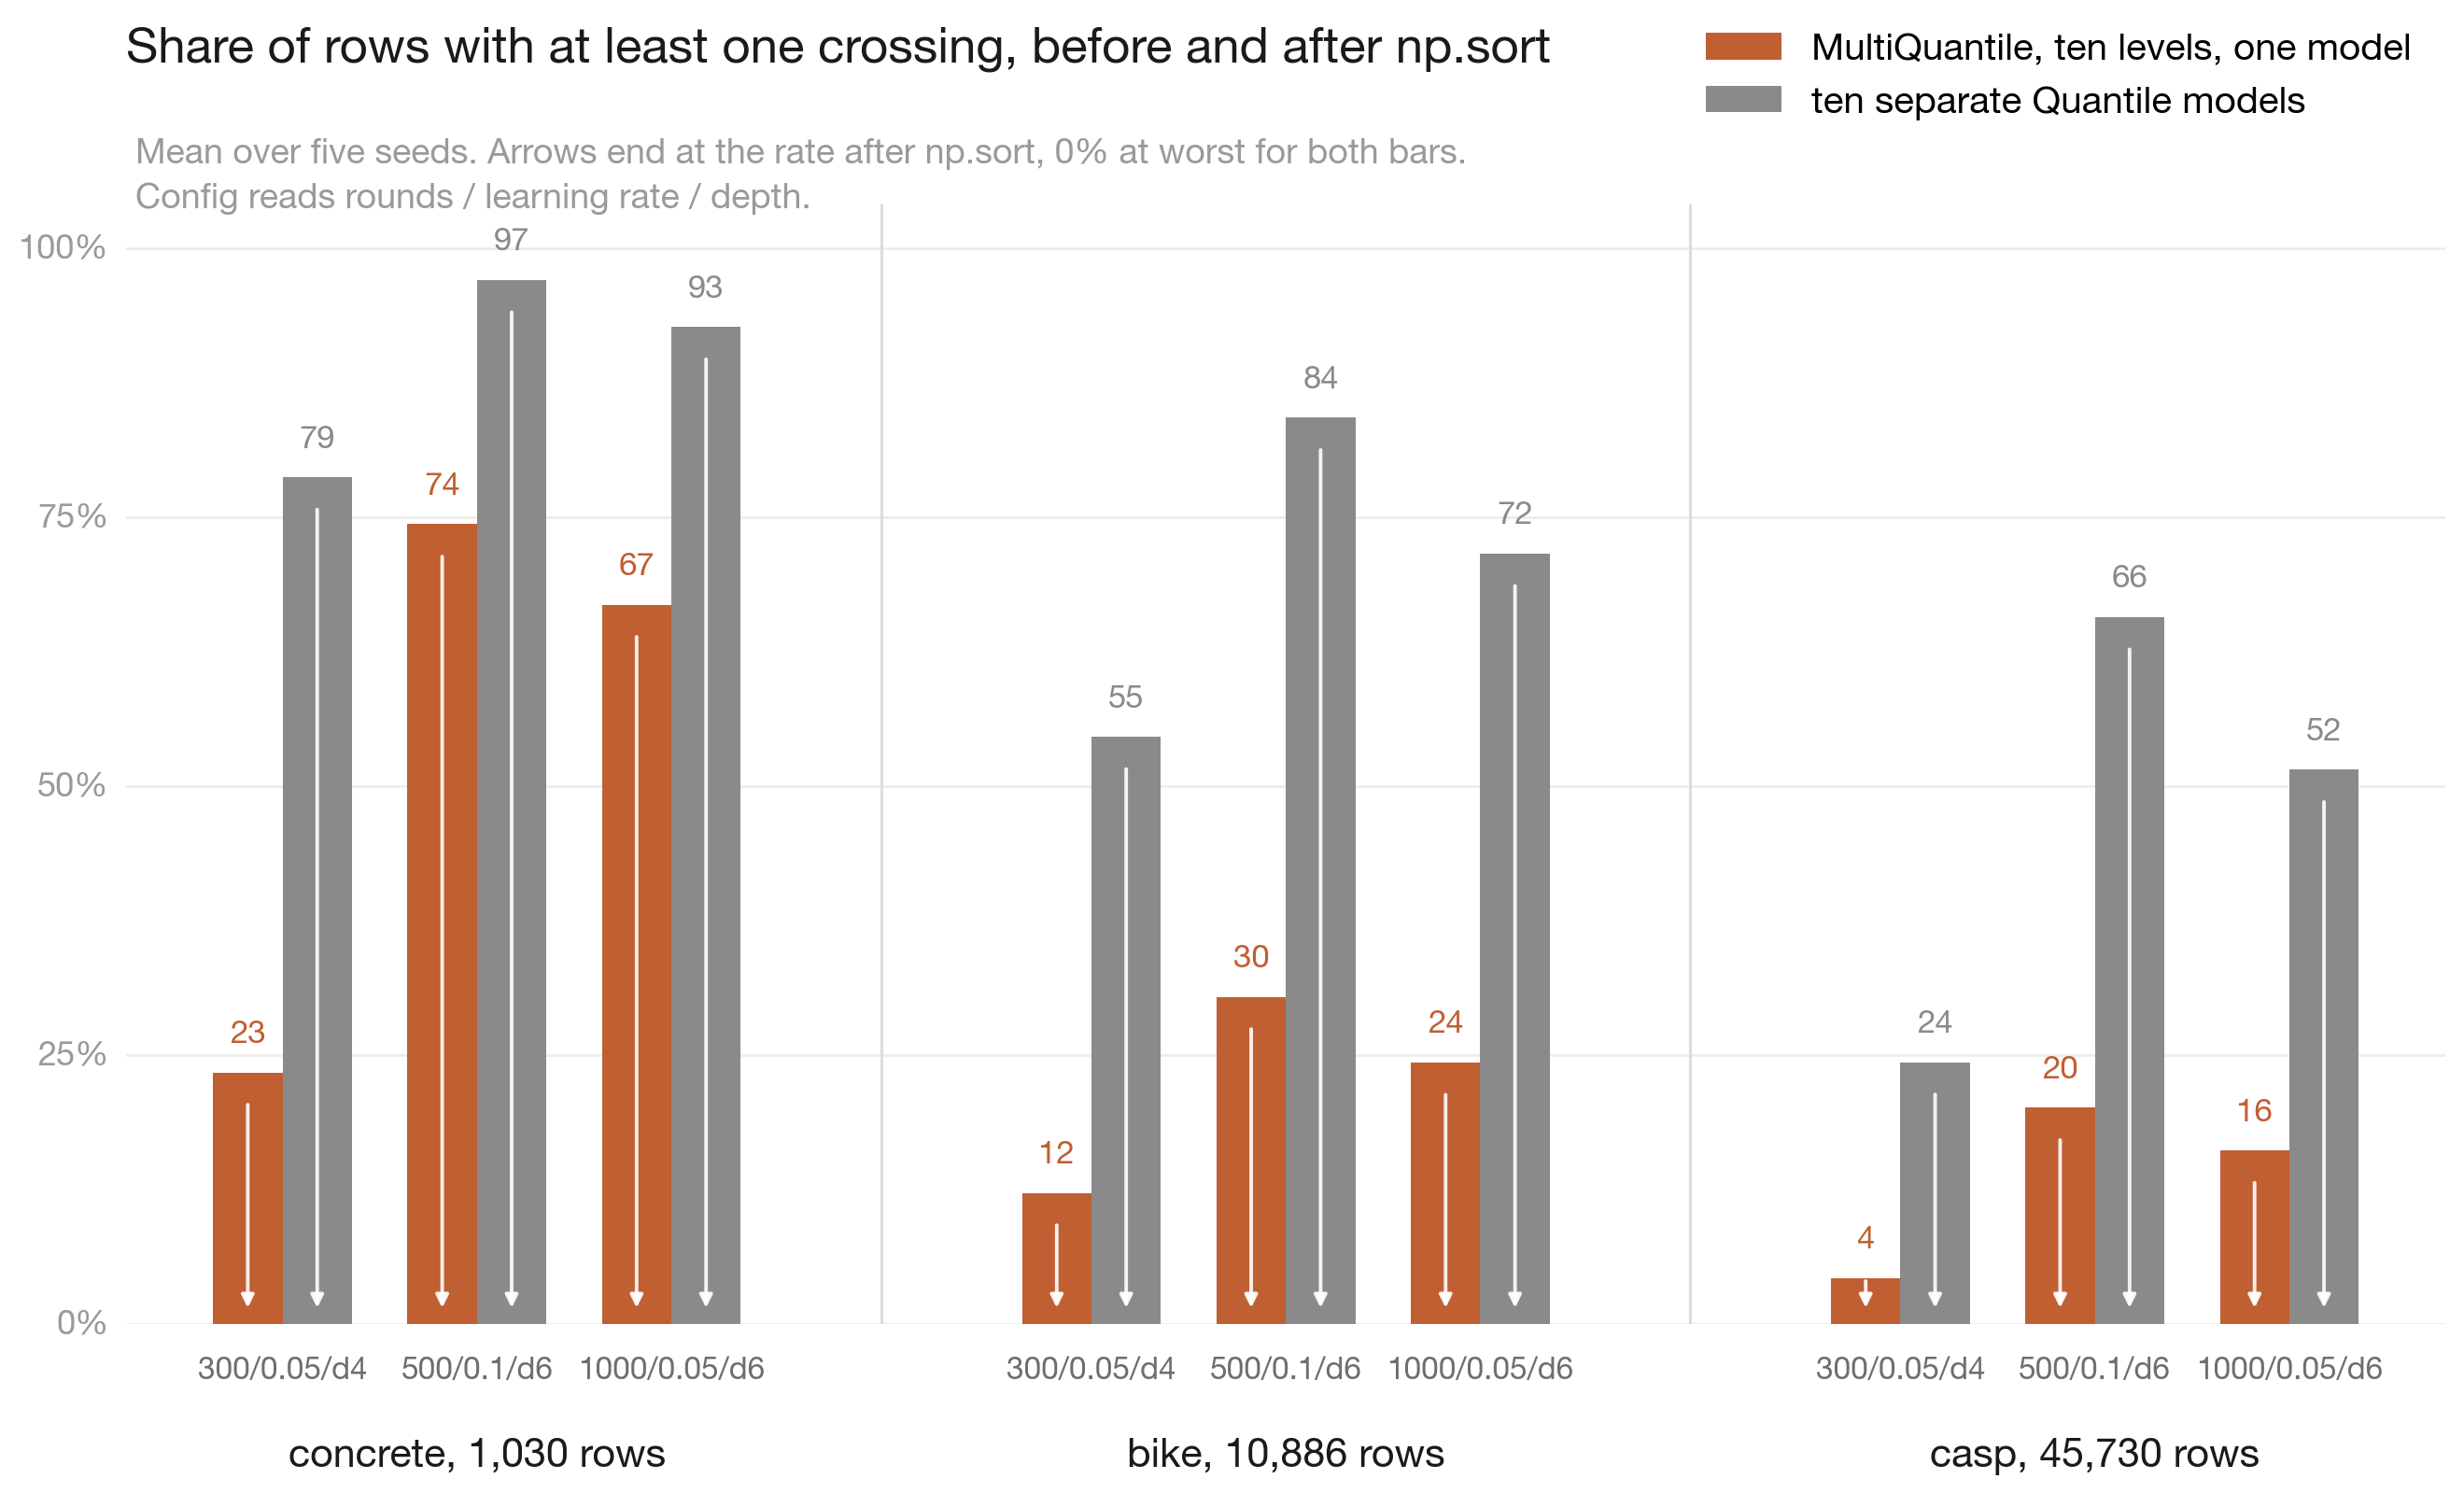

In [18]:
# colour by column name, so reordering the columns can never swap the bars
CROSS_ARMS = [("one model", CORAL_E, "MultiQuantile, ten levels, one model"),
              ("ten models", GREY_E, "ten separate Quantile models")]
worst_after = grid_mean[[f"{k} sorted, crossing %" for k, _, _ in CROSS_ARMS]].max().max()
BAR_W, PAIR_GAP, PANEL_GAP = 0.40, 1.12, 1.30
TICKS = (0, 25, 50, 75, 100)

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
fig.patch.set_facecolor("white")
ax = fig.add_axes([0.055, 0.155, 0.90, 0.75])
ax.set_ylim(0, 112)
ax.axis("off")
for tick in TICKS:                                   # horizontal guides in place of a grid
    ax.axhline(tick, color=GUIDE_GREY, lw=1.0, zorder=1)

cursor = 0.0
for di, (ds, (_, ycol)) in enumerate(DATA.items()):
    first = cursor
    for ci, cfg_name in enumerate(CONFIGS):
        centre = cursor + ci*PAIR_GAP
        row = grid_mean.loc[(ds, cfg_name)]
        for ai, (key, colour, _) in enumerate(CROSS_ARMS):
            before, after = row[f"{key}, crossing %"], row[f"{key} sorted, crossing %"]
            bx = centre + (ai - 0.5)*BAR_W
            ax.bar(bx, before, width=BAR_W, color=colour, zorder=3)
            ax.text(bx, before + 2.2, f"{before:.0f}", ha="center", va="bottom", fontsize=12.5,
                    color=colour)
            ax.annotate("", xy=(bx, after + 1.5), xytext=(bx, max(before - 3.0, after + 4.0)),
                        arrowprops=dict(arrowstyle="-|>", color="white", lw=1.4, alpha=0.9,
                                        shrinkA=0, shrinkB=0), zorder=4)
        ax.text(centre, -3.0, cfg_name, ha="center", va="top", fontsize=12, color=TEXT_MUTED)
    last = cursor + 2*PAIR_GAP
    ax.text((first + last)/2, -10.5, f"{ds}, {len(ycol):,} rows", ha="center", va="top",
            fontsize=15.5, color=INK, fontweight="bold")
    if di < len(DATA) - 1:
        ax.plot([last + (PANEL_GAP + PAIR_GAP)/2]*2, [0, 104], color="#dcdcdc", lw=1.1, zorder=2)
    cursor = last + PANEL_GAP + PAIR_GAP

ax.set_xlim(-0.9, cursor - PANEL_GAP - PAIR_GAP + 0.9)
for tick in TICKS:
    ax.text(-1.0, tick, f"{tick}%", ha="right", va="center", fontsize=13, color=TEXT_FAINT)

ax.text(0.004, 0.985, f"Mean over five seeds. Arrows end at the rate after np.sort, "
        f"{worst_after:g}% at worst for both bars.\nConfig reads rounds / learning rate / depth.",
        transform=ax.transAxes, ha="left", va="top", fontsize=13.5, style="italic",
        color=TEXT_FAINT, linespacing=1.5)
ax.text(0.0, 1.04, "Share of rows with at least one crossing, before and after np.sort",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=19, color=INK)
ax.legend(handles=[Patch(facecolor=c, label=lab) for _, c, lab in CROSS_ARMS],
          loc="upper right", frameon=False, fontsize=14.5, bbox_to_anchor=(1.0, 1.10), ncol=1)
plt.show()

## Takeaway

The nominal level is a fitting target. On held-out rows every seed-averaged band here came in under
it, and how hard the trees were fitted moved every arm, the ten-level arm most.

`MultiQuantile` is a real saving when a whole grid of levels is wanted, and it crossed on 4% to 74%
of rows against 24% to 97% for separate fits. Part of the saving is that it builds one ensemble
where the separate fits build ten, which is also why its outer pair narrows once the fit is hard.
It is not the best answer to crossing either: sorting each row removes crossings outright, and ten
separate fits plus a sort landed the individual levels closer than the joint model as fitted in all
nine settings, and closer than the joint model plus a sort in eight of them.

Conformalizing is the only step here that put the band on the level it claimed, down to a pool of
500 rows on average, though single seeds at that size ran from 86% to 94%. It costs the calibration
rows, and cross-conformal variants exist to avoid paying that in one lump.

One limit worth repeating: conformal coverage is marginal. It holds over the test set as a whole
and says nothing about any particular slice of it. No arm here used early stopping or a tuned
validation set either, so read the harder settings as deliberately over-fitted rather than as
advice.